# Penyelesaian Missing Value Konsentrasi 4 Polutan (CH4, CO, NO2, SO2) Menggunakan Metode Interpolasi Linear Bertahap

**Dataset Input**: `data/csv/pertemuan-4-csv/polutan_4_clean.csv` (Hasil Pembersihan Outlier 365 Hari)  
**Tujuan**: Menangani dan menambal nilai-nilai yang hilang (*missing values* asli dan bekas pencilan yang di-NaN-kan) pada 4 polutan udara (`CH4`, `CO`, `NO2`, `SO2`) menggunakan metode **Interpolasi Linear Bertahap**. Proses ini menghasilkan dataset deret waktu tahunan yang bersih sempurna (*final clean dataset*) sepanjang 365 hari lengkap (0 NaN) yang siap untuk ekstraksi fitur TSFEL.

## Tahap 1: Memuat Data Bebas Outlier dan Eksplorasi Profil Missing Values 4 Polutan

=== PROFIL DATASET BEBAS OUTLIER 4 POLUTAN (HARI 1 - 365) ===
Total Baris Data        : 365 hari
Rentang Tanggal         : 2025-08-24 s.d. 2026-08-23


,Polutan,Total Hari,Data Valid (Hari),Persentase Valid,Missing Values (Hari),Persentase Missing
0,CH4,365,27,7.40%,338,92.60%
1,CO,365,233,63.84%,132,36.16%
2,NO2,365,203,55.62%,162,44.38%
3,SO2,365,244,66.85%,121,33.15%


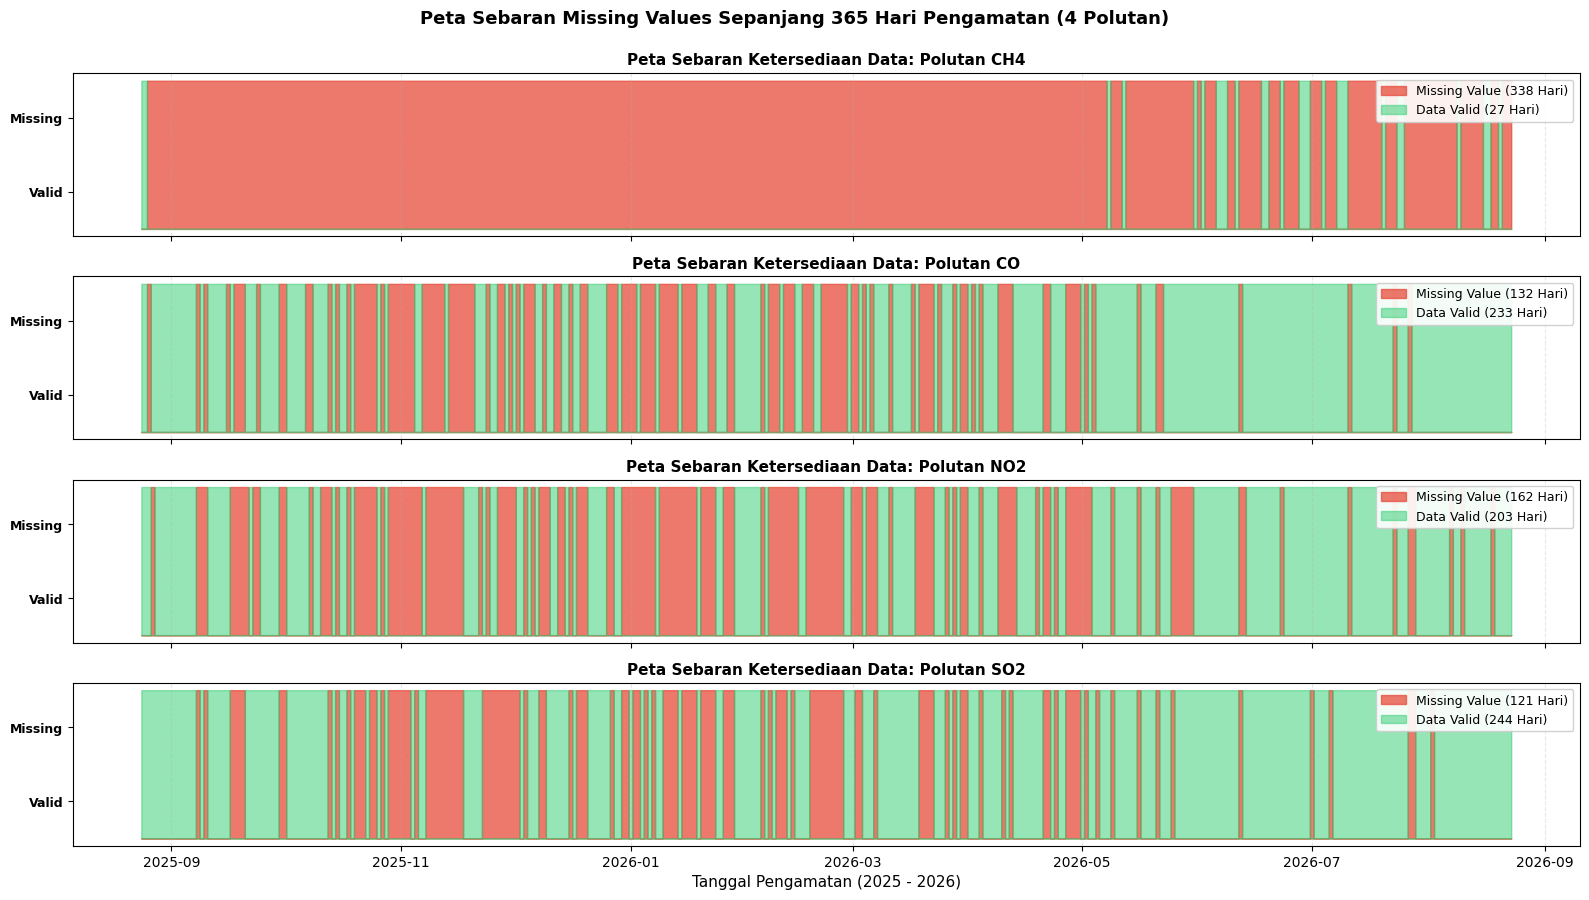

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Pemuatan dataset bersih bebas outlier hasil dari detec-outlier-4-polutan.ipynb
input_path = "../data/csv/pertemuan-4-csv/polutan_4_clean.csv"
if not os.path.exists(input_path):
    input_path = "data/csv/pertemuan-4-csv/polutan_4_clean.csv"

df = pd.read_csv(input_path)
df['tanggal'] = pd.to_datetime(df['tanggal'])
pollutants = ['CH4', 'CO', 'NO2', 'SO2']

# 2. Profil ketersediaan data dan missing value 4 polutan
profil_list = []
for p in pollutants:
    n_valid = df[p].notna().sum()
    n_missing = df[p].isna().sum()
    pct_valid = (n_valid / len(df)) * 100
    pct_missing = (n_missing / len(df)) * 100
    profil_list.append({
        'Polutan': p,
        'Total Hari': len(df),
        'Data Valid (Hari)': n_valid,
        'Persentase Valid': f"{pct_valid:.2f}%",
        'Missing Values (Hari)': n_missing,
        'Persentase Missing': f"{pct_missing:.2f}%"
    })

df_profil = pd.DataFrame(profil_list)

print("=== PROFIL DATASET BEBAS OUTLIER 4 POLUTAN (HARI 1 - 365) ===")
print(f"Total Baris Data        : {len(df)} hari")
print(f"Rentang Tanggal         : {df['tanggal'].min().strftime('%Y-%m-%d')} s.d. {df['tanggal'].max().strftime('%Y-%m-%d')}")
display(df_profil)

# 3. Visualisasi Peta Sebaran Missing Value 4 Polutan
fig, axes = plt.subplots(4, 1, figsize=(16, 9), sharex=True)
colors = {'CH4': '#1f77b4', 'CO': '#ff7f0e', 'NO2': '#2ca02c', 'SO2': '#9467bd'}

for i, p in enumerate(pollutants):
    ax = axes[i]
    mask = df[p].isna().astype(int)
    n_miss = df[p].isna().sum()
    n_val = df[p].notna().sum()
    
    ax.fill_between(df['tanggal'], 0, mask, color='#e74c3c', alpha=0.75, step='mid', label=f'Missing Value ({n_miss} Hari)')
    ax.fill_between(df['tanggal'], 0, 1 - mask, color='#2ecc71', alpha=0.5, step='mid', label=f'Data Valid ({n_val} Hari)')
    ax.set_yticks([0.25, 0.75])
    ax.set_yticklabels(['Valid', 'Missing'], fontsize=9, fontweight='bold')
    ax.set_title(f'Peta Sebaran Ketersediaan Data: Polutan {p}', fontsize=11, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.3, axis='x')
    ax.legend(loc='upper right', framealpha=0.9, fontsize=9)

axes[-1].set_xlabel('Tanggal Pengamatan (2025 - 2026)', fontsize=11)
plt.suptitle('Peta Sebaran Missing Values Sepanjang 365 Hari Pengamatan (4 Polutan)', fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


## Tahap 2: Rumus Matematis & Komparasi Metode Imputasi

Dalam deret waktu (*time series*), nilai pengamatan pada waktu $t$ memiliki ketergantungan temporal (*autokorelasi*) terhadap waktu sebelumnya ($t_0$) dan sesudahnya ($t_1$).

### 1. Formula Matematis Interpolasi Linear:
Untuk suatu titik data yang hilang pada waktu $t$ di antara dua titik observasi valid $(t_0, y_0)$ dan $(t_1, y_1)$:
$$y(t) = y_0 + (t - t_0) \times \frac{y_1 - y_0}{t_1 - t_0}$$

### 2. Keunggulan Dibandingkan Metode Lain:
* **Mean Imputation**: Mengisi seluruh celah data dengan nilai rata-rata konstan ($\mu$). Kelemahannya adalah merusak struktur variansi data dan menciptakan garis datar artifisial yang tidak realistis.
* **Forward Fill (Last Observation Carried Forward)**: Menyalin nilai terakhir yang valid. Kelemahannya adalah menghasilkan kurva tangga (*step function*) patah-patah yang mendistorsi turunan laju perubahan data.
* **Interpolasi Linear**: Menghubungkan titik observasi terdekat secara kontinu dan mulus dengan laju perubahan proporsional terhadap jarak interval waktu.

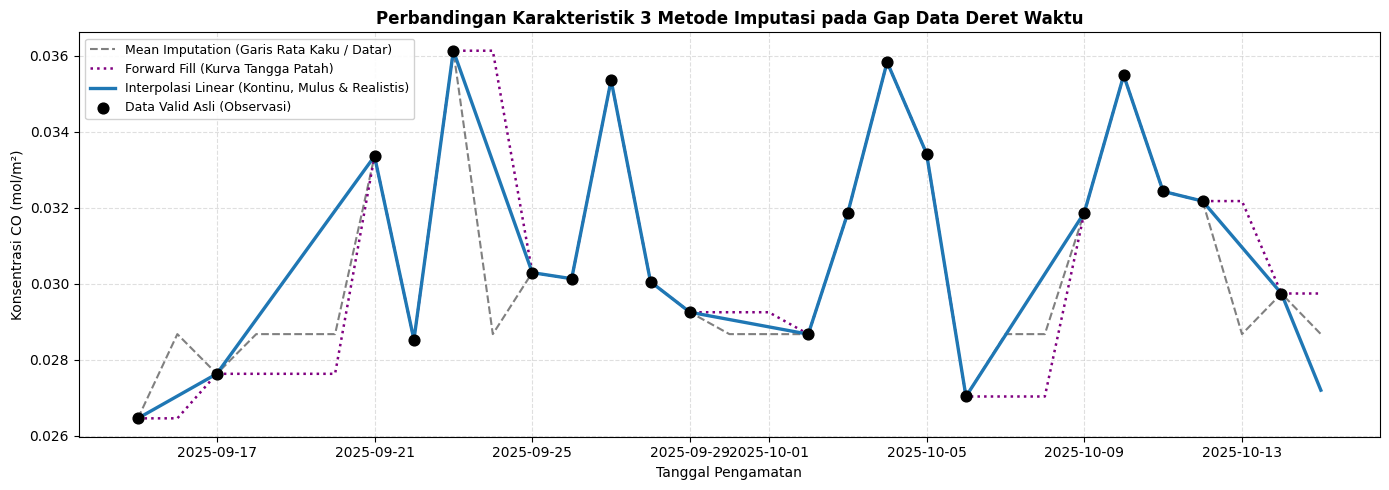

In [2]:
# Komparasi Karakteristik 3 Metode Imputasi pada Gap Sampel Data CO
df_comp = df.copy()
df_comp['CO_mean'] = df_comp['CO'].fillna(df_comp['CO'].mean())
df_comp['CO_ffill'] = df_comp['CO'].ffill().bfill()
df_comp['CO_linear'] = df_comp['CO'].interpolate(method='linear')

zoom_mask = (df_comp['tanggal'] >= '2025-09-15') & (df_comp['tanggal'] <= '2025-10-15')
df_z = df_comp[zoom_mask]

plt.figure(figsize=(14, 5))
plt.plot(df_z['tanggal'], df_z['CO_mean'], label='Mean Imputation (Garis Rata Kaku / Datar)', linestyle='--', color='gray', linewidth=1.5)
plt.plot(df_z['tanggal'], df_z['CO_ffill'], label='Forward Fill (Kurva Tangga Patah)', linestyle=':', color='purple', linewidth=1.8)
plt.plot(df_z['tanggal'], df_z['CO_linear'], label='Interpolasi Linear (Kontinu, Mulus & Realistis)', color='#1f77b4', linewidth=2.4)
plt.scatter(df_z.dropna(subset=['CO'])['tanggal'], df_z.dropna(subset=['CO'])['CO'], color='black', s=60, zorder=5, label='Data Valid Asli (Observasi)')
plt.title('Perbandingan Karakteristik 3 Metode Imputasi pada Gap Data Deret Waktu', fontsize=12, fontweight='bold')
plt.xlabel('Tanggal Pengamatan', fontsize=10)
plt.ylabel('Konsentrasi CO (mol/m²)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(framealpha=0.9, fontsize=9)
plt.tight_layout()
plt.show()


## Tahap 3: Penerapan Interpolasi Linear Secara Bertahap untuk 4 Polutan

Pada tahap ini, fungsi interpolasi linear diterapkan secara berurutan pada ke-4 polutan udara (`CH4`, `CO`, `NO2`, `SO2`). Untuk titik-titik di batas awal atau batas akhir rentang waktu yang tidak memiliki tetangga pengapit, diterapkan kombinasi *backward fill* (`bfill`) dan *forward fill* (`ffill`) sehingga seluruh 365 baris data terisi sempurna 100%.

In [3]:
df_imputed = df.copy()

rekap_imputasi = []

for p in pollutants:
    # Catat posisi data yang hilang
    is_miss = df[p].isna()
    df_imputed[f'{p}_is_imputed'] = is_miss
    
    # Penerapan interpolasi linear + boundary fill
    df_imputed[p] = df[p].interpolate(method='linear').bfill().ffill()
    
    n_asli = (~is_miss).sum()
    n_tambal = is_miss.sum()
    sisa_nan = df_imputed[p].isna().sum()
    
    rekap_imputasi.append({
        'Polutan': p,
        'Total Hari': len(df_imputed),
        'Data Asli Valid': n_asli,
        'Data Ditambal (Interpolasi)': n_tambal,
        'Persentase Ditambal': f"{(n_tambal / len(df_imputed) * 100):.2f}%",
        'Sisa Missing (NaN)': sisa_nan,
        'Status': '100% LENGKAP ✓' if sisa_nan == 0 else 'ADA SISA NaN ✗'
    })

df_rekap_imp = pd.DataFrame(rekap_imputasi)
print("=" * 85)
print("HASIL PENERAPAN INTERPOLASI LINEAR PADA 4 POLUTAN (365 HARI LENGKAP)")
print("=" * 85)
display(df_rekap_imp)

print("\n--- 10 Baris Pertama Data Hasil Penambalan ---")
display(df_imputed[['tanggal'] + pollutants].head(10))


HASIL PENERAPAN INTERPOLASI LINEAR PADA 4 POLUTAN (365 HARI LENGKAP)


,Polutan,Total Hari,Data Asli Valid,Data Ditambal (Interpolasi),Persentase Ditambal,Sisa Missing (NaN),Status
0,CH4,365,27,338,92.60%,0,100% LENGKAP ✓
1,CO,365,233,132,36.16%,0,100% LENGKAP ✓
2,NO2,365,203,162,44.38%,0,100% LENGKAP ✓
3,SO2,365,244,121,33.15%,0,100% LENGKAP ✓



--- 10 Baris Pertama Data Hasil Penambalan ---


,tanggal,CH4,CO,NO2,SO2
0,2025-08-24,1850.206787,0.032369,0.000030,0.000544
1,2025-08-25,1867.289429,0.029644,0.000040,0.000182
2,2025-08-26,1867.369420,0.029057,0.000046,-0.000258
3,2025-08-27,1867.449411,0.028471,0.000038,0.000107
4,2025-08-28,1867.529402,0.024230,0.000029,-0.000066
5,2025-08-29,1867.609392,0.027042,0.000029,0.000308
6,2025-08-30,1867.689383,0.026769,0.000006,0.000086
7,2025-08-31,1867.769374,0.027958,0.000019,0.000141
8,2025-09-01,1867.849365,0.025399,0.000033,0.000093
9,2025-09-02,1867.929356,0.022620,0.000014,0.000163


## Tahap 4: Visualisasi Hasil Imputasi Linear (4 Polutan)

Menampilkan visualisasi komprehensif 365 hari penuh dari hasil interpolasi linear untuk ke-4 polutan, memperlihatkan pembedaan yang jelas antara titik data asli (valid) dan titik data hasil interpolasi linear (ditambal).

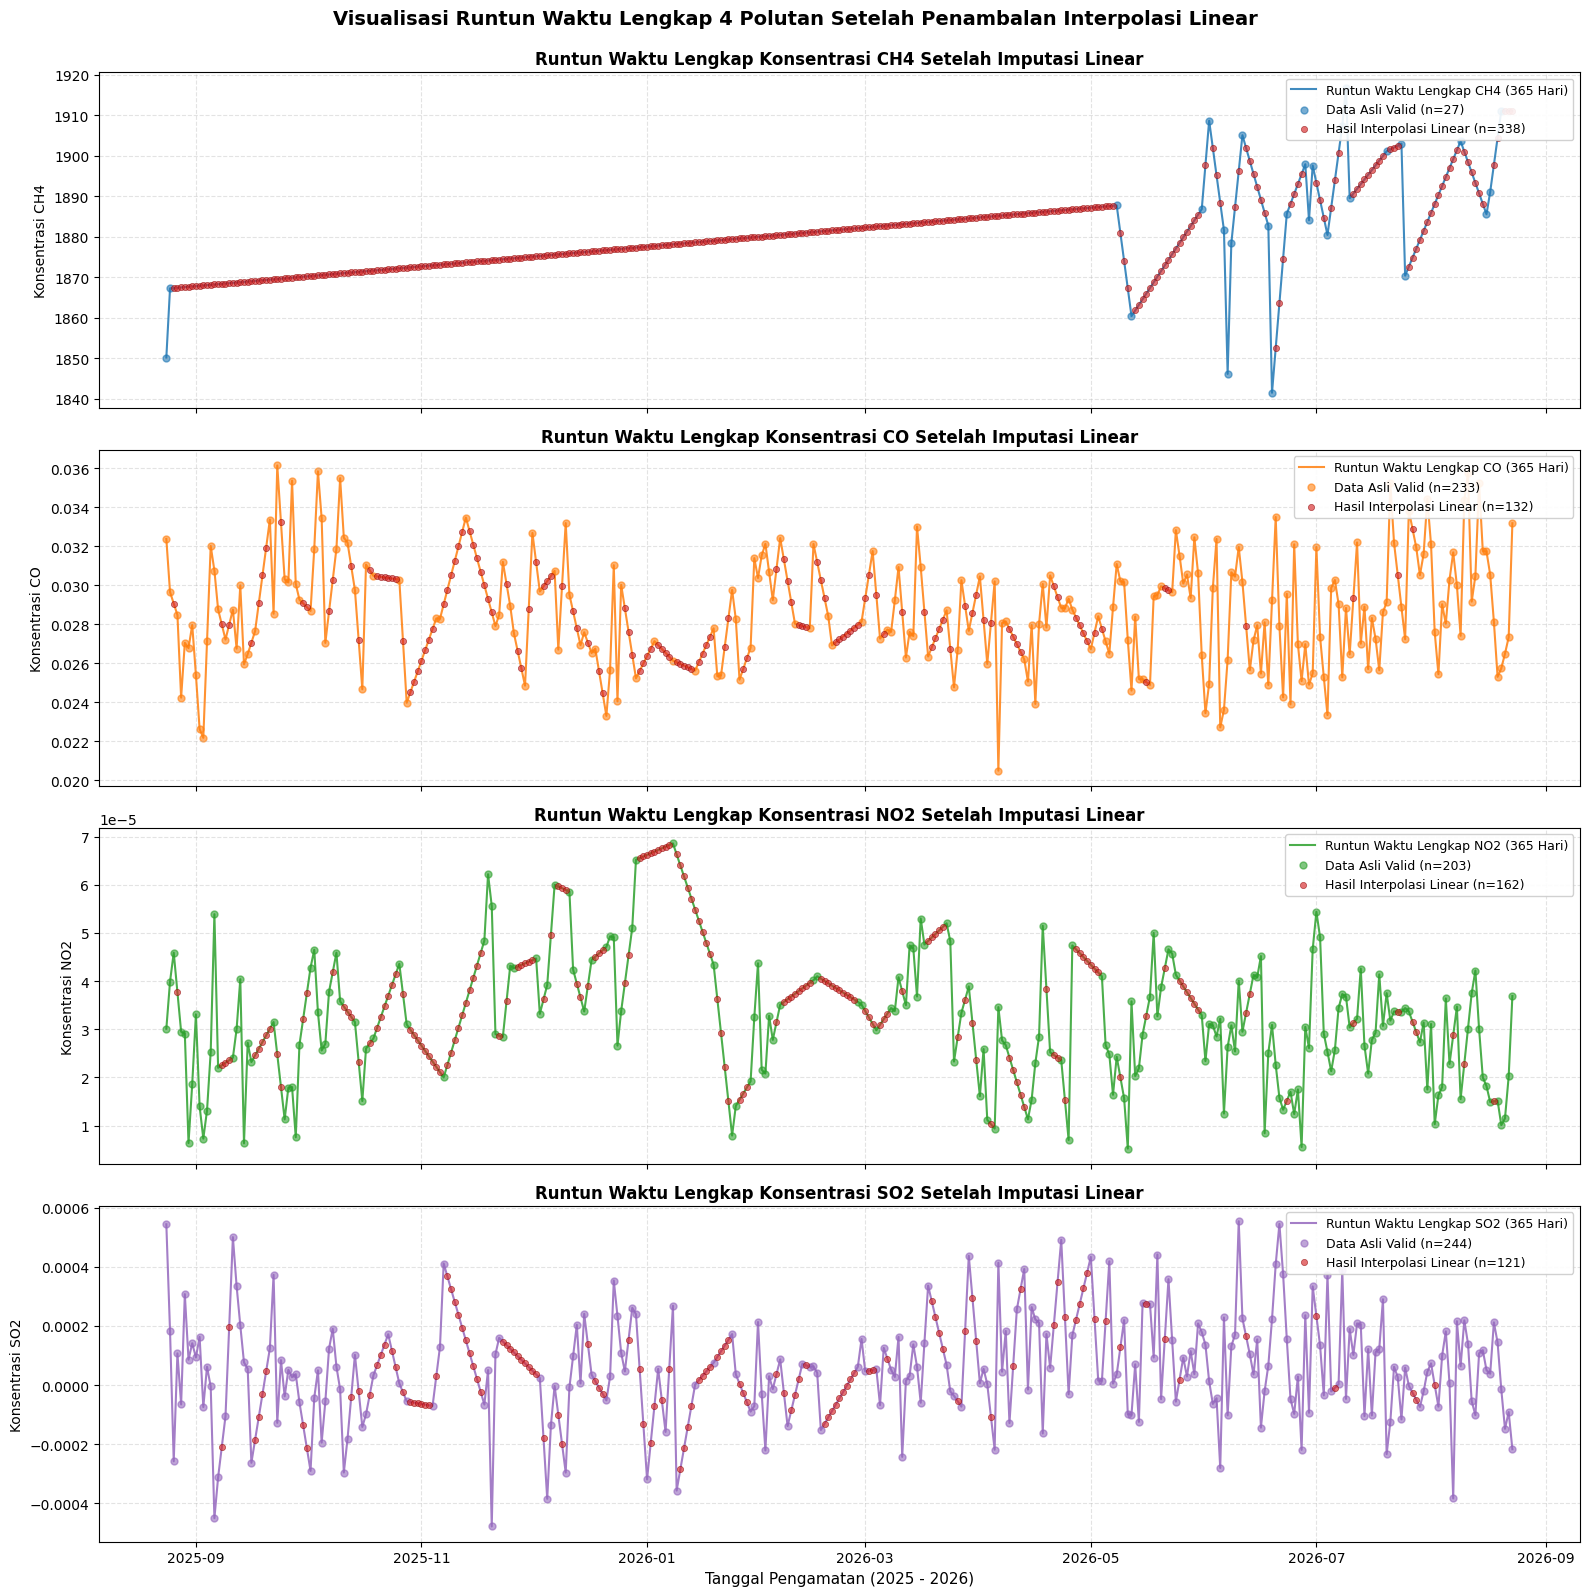

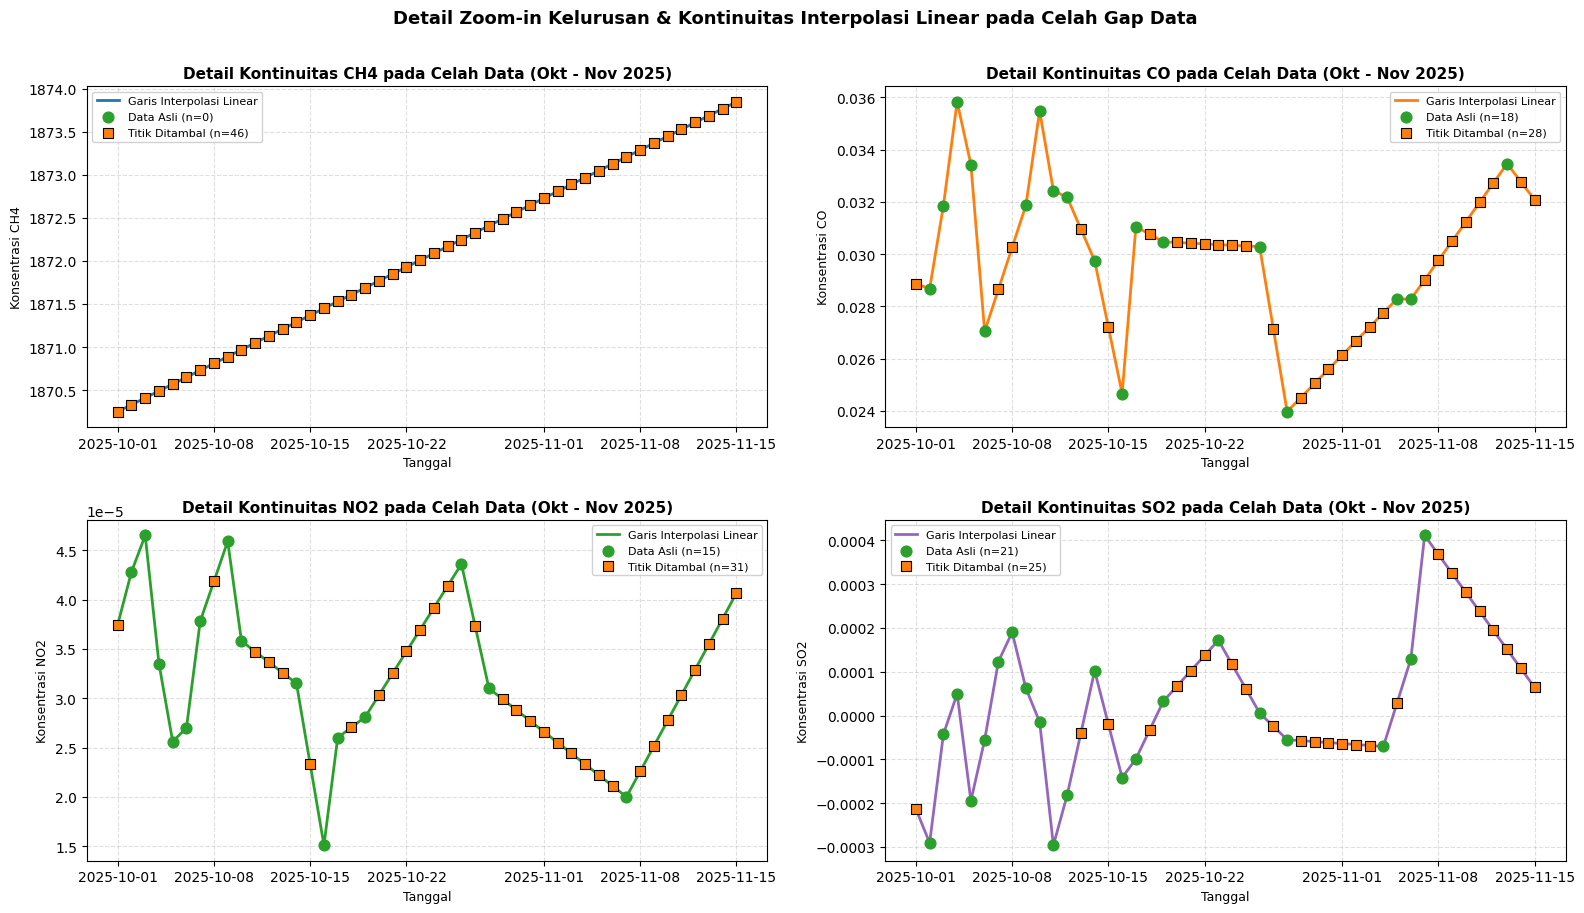

In [4]:
# 1. Visualisasi Full Time Series 365 Hari Hasil Imputasi (4 Polutan)
fig, axes = plt.subplots(4, 1, figsize=(16, 16), sharex=True)

for i, p in enumerate(pollutants):
    ax = axes[i]
    is_miss = df_imputed[f'{p}_is_imputed']
    
    # Garis kontinu hasil interpolasi
    ax.plot(df_imputed['tanggal'], df_imputed[p], color=colors[p], linewidth=1.5, alpha=0.85, label=f'Runtun Waktu Lengkap {p} (365 Hari)')
    
    # Scatter data asli
    ax.scatter(df_imputed.loc[~is_miss, 'tanggal'], df_imputed.loc[~is_miss, p],
               color=colors[p], s=25, alpha=0.6, label=f'Data Asli Valid (n={(~is_miss).sum()})')
    
    # Scatter data hasil penambalan (interpolasi)
    ax.scatter(df_imputed.loc[is_miss, 'tanggal'], df_imputed.loc[is_miss, p],
               color='#d62728', marker='o', s=20, alpha=0.65, edgecolor='darkred', linewidth=0.5, zorder=4,
               label=f'Hasil Interpolasi Linear (n={is_miss.sum()})')
    
    ax.set_title(f'Runtun Waktu Lengkap Konsentrasi {p} Setelah Imputasi Linear', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'Konsentrasi {p}', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.35)
    ax.legend(loc='upper right', framealpha=0.9, fontsize=9)

axes[-1].set_xlabel('Tanggal Pengamatan (2025 - 2026)', fontsize=11)
plt.suptitle('Visualisasi Runtun Waktu Lengkap 4 Polutan Setelah Penambalan Interpolasi Linear', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# 2. Visualisasi Detail Zoom-in Kontinuitas Interpolasi pada Celah Data
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()

zoom_range = (df_imputed['tanggal'] >= '2025-10-01') & (df_imputed['tanggal'] <= '2025-11-15')
df_zoom = df_imputed[zoom_range]

for i, p in enumerate(pollutants):
    ax = axes[i]
    z_miss = df_zoom[f'{p}_is_imputed']
    
    ax.plot(df_zoom['tanggal'], df_zoom[p], color=colors[p], linewidth=2.0, label='Garis Interpolasi Linear')
    ax.scatter(df_zoom.loc[~z_miss, 'tanggal'], df_zoom.loc[~z_miss, p],
               color='#2ca02c', s=60, zorder=5, label=f'Data Asli (n={(~z_miss).sum()})')
    ax.scatter(df_zoom.loc[z_miss, 'tanggal'], df_zoom.loc[z_miss, p],
               color='#ff7f0e', marker='s', s=55, edgecolor='black', linewidth=0.8, zorder=5,
               label=f'Titik Ditambal (n={z_miss.sum()})')
    
    ax.set_title(f'Detail Kontinuitas {p} pada Celah Data (Okt - Nov 2025)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Tanggal', fontsize=9)
    ax.set_ylabel(f'Konsentrasi {p}', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='best', framealpha=0.9, fontsize=8)

plt.suptitle('Detail Zoom-in Kelurusan & Kontinuitas Interpolasi Linear pada Celah Gap Data', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## Tahap 5: Ekspor Data Bersih Sempurna (Final Clean Dataset)

Menyimpan dataset akhir 4 polutan yang telah 100% bebas dari missing value dan bebas outlier ke berkas `polutan_4_final_clean.csv`. Berkas ini merupakan input siap pakai (*ready-to-use*) untuk tahapan ekstraksi fitur TSFEL pada notebook `ekstaksi-fitur-4-polutan.ipynb`.

In [5]:
# 1. Penyusunan DataFrame Final Bersih Sempurna
output_folder = "../data/csv/pertemuan-4-csv"
if not os.path.exists(output_folder):
    output_folder = "data/csv/pertemuan-4-csv"
os.makedirs(output_folder, exist_ok=True)

df_final = pd.DataFrame({
    'tanggal': df_imputed['tanggal'].dt.strftime('%Y-%m-%d'),
    'CH4': df_imputed['CH4'],
    'CO': df_imputed['CO'],
    'NO2': df_imputed['NO2'],
    'SO2': df_imputed['SO2']
})

final_csv_path = os.path.join(output_folder, "polutan_4_final_clean.csv")
df_final.to_csv(final_csv_path, index=False)
print(f"✓ Berkas data bersih sempurna berhasil disimpan di:\n  {final_csv_path}")

# 2. Verifikasi Integritas dan Statistik Akhir Dataset
print("\n" + "=" * 90)
print("VERIFIKASI AKHIR DATASET 4 POLUTAN LENGKAP (365 HARI)")
print("=" * 90)

df_check = pd.read_csv(final_csv_path)
print(f"Total Baris Data        : {len(df_check)} baris (Tepat 365 hari lengkap)")
print(f"Rentang Waktu           : {df_check['tanggal'].min()} s.d. {df_check['tanggal'].max()}")
print(f"Total Missing Values    : {df_check.isna().sum().sum()} baris (0 NaN di semua kolom)")

stat_final = []
for p in pollutants:
    s = df_check[p]
    stat_final.append({
        'Polutan': p,
        'Jumlah Baris': len(s),
        'Missing Values': s.isna().sum(),
        'Nilai Min': f"{s.min():.6e}",
        'Rata-rata (μ)': f"{s.mean():.6e}",
        'Nilai Max': f"{s.max():.6e}",
        'Std Dev (σ)': f"{s.std():.6e}"
    })

df_stat_final = pd.DataFrame(stat_final)
display(df_stat_final)

print("\n--- 5 Baris Pertama Dataset Bersih Sempurna ---")
display(df_check.head())


✓ Berkas data bersih sempurna berhasil disimpan di:
  ../data/csv/pertemuan-4-csv\polutan_4_final_clean.csv

VERIFIKASI AKHIR DATASET 4 POLUTAN LENGKAP (365 HARI)
Total Baris Data        : 365 baris (Tepat 365 hari lengkap)
Rentang Waktu           : 2025-08-24 s.d. 2026-08-23
Total Missing Values    : 0 baris (0 NaN di semua kolom)


,Polutan,Jumlah Baris,Missing Values,Nilai Min,Rata-rata (μ),Nilai Max,Std Dev (σ)
0,CH4,365,0,1.841516e+03,1.880449e+03,1.916853e+03,1.041489e+01
1,CO,365,0,2.048735e-02,2.858408e-02,3.613363e-02,2.598121e-03
2,NO2,365,0,5.230000e-06,3.359174e-05,6.860000e-05,1.319949e-05
3,SO2,365,0,-4.784350e-04,5.495878e-05,5.539490e-04,1.696823e-04



--- 5 Baris Pertama Dataset Bersih Sempurna ---


,tanggal,CH4,CO,NO2,SO2
0,2025-08-24,1850.206787,0.032369,0.000030,0.000544
1,2025-08-25,1867.289429,0.029644,0.000040,0.000182
2,2025-08-26,1867.369420,0.029057,0.000046,-0.000258
3,2025-08-27,1867.449411,0.028471,0.000038,0.000107
4,2025-08-28,1867.529402,0.024230,0.000029,-0.000066
